# <center>Titanic Missing Value Handling<center>

## 1.Data Analysing

In [1]:
pd.read_csv("titanic.csv")

NameError: name 'pd' is not defined

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
titanic_df=pd.read_csv("titanic.csv")

In [14]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<Axes: >

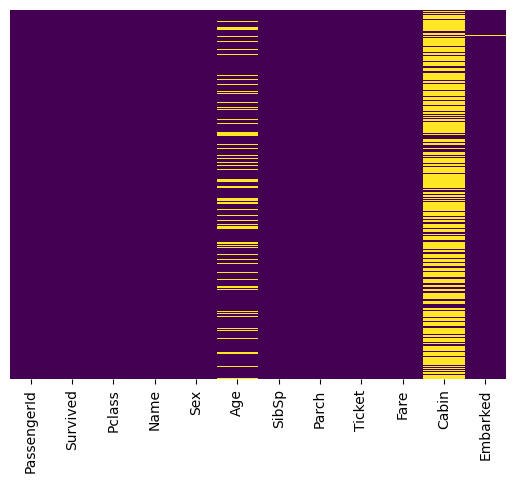

In [23]:
sns.heatmap(titanic_df.isnull(),yticklabels=False, cbar=False, cmap='viridis')


In [24]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: xlabel='Survived', ylabel='count'>

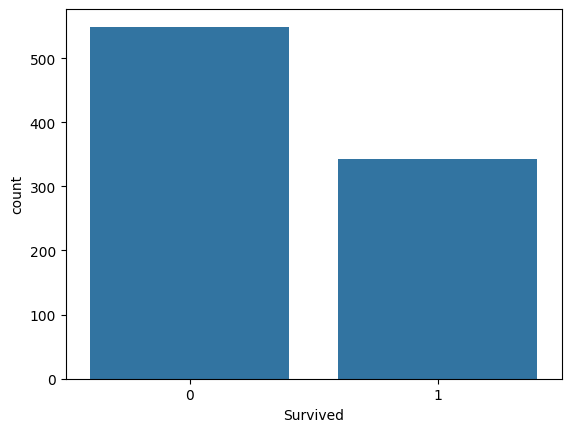

In [29]:
sns.countplot(x='Survived' ,data=titanic_df)

<Axes: xlabel='Sex', ylabel='count'>

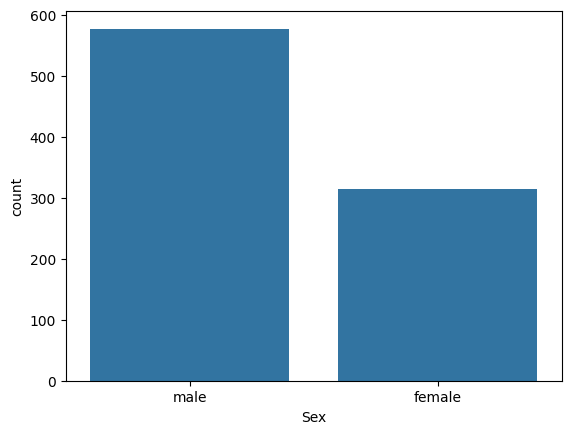

In [30]:
sns.countplot(x='Sex' ,data=titanic_df)

<Axes: xlabel='Survived', ylabel='count'>

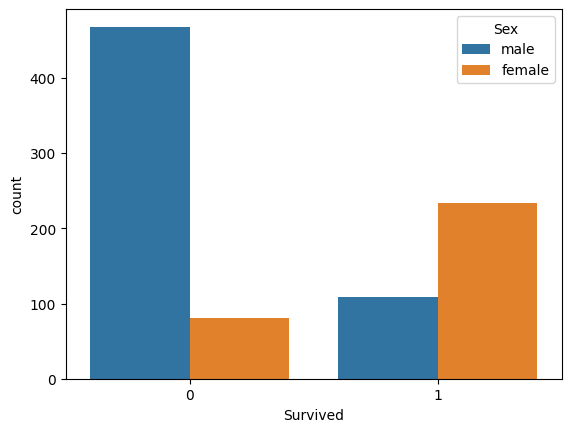

In [33]:
sns.countplot(x='Survived', hue='Sex',data=titanic_df)

<Axes: xlabel='Pclass', ylabel='count'>

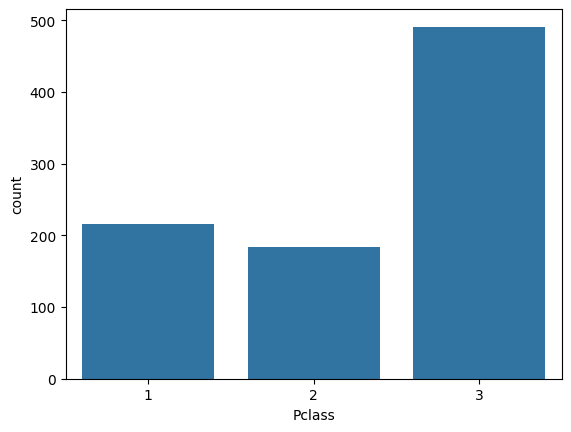

In [34]:
sns.countplot(x='Pclass', data=titanic_df)

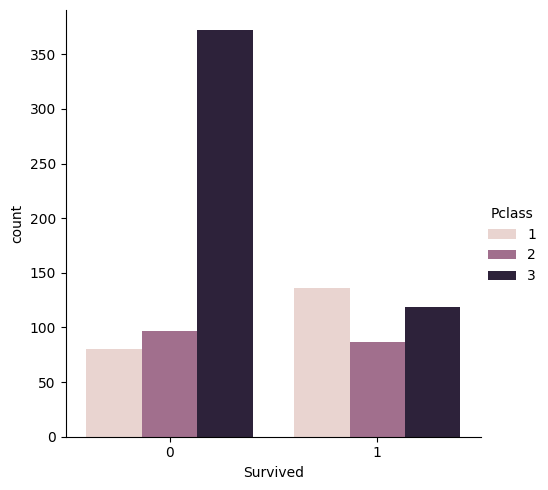

In [37]:
sns.catplot(x='Survived', data=titanic_df, hue='Pclass', kind='count')

<Axes: >

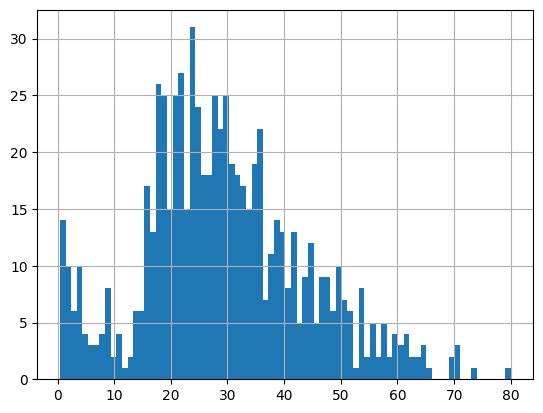

In [40]:
titanic_df['Age'].hist(bins=80)

<Axes: >

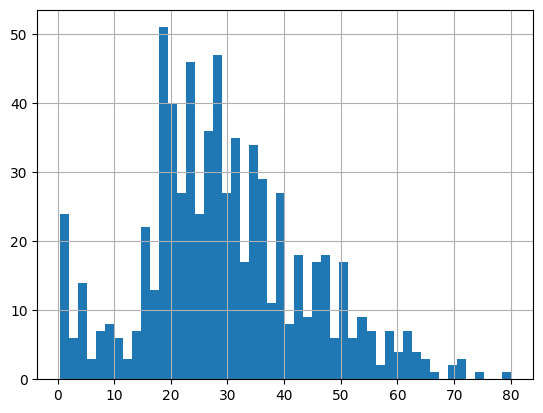

In [41]:
titanic_df['Age'].hist(bins=50)

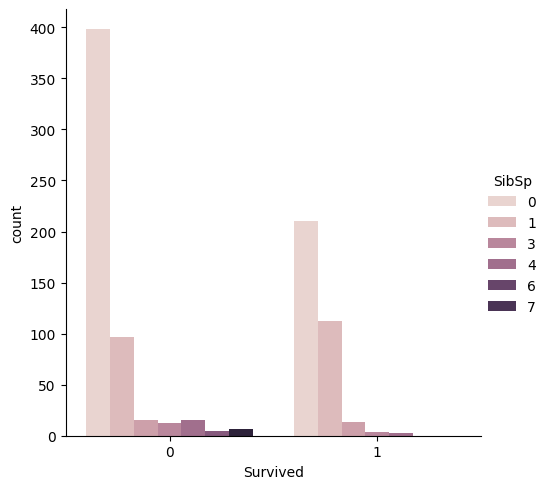

In [44]:
sns.catplot(x='Survived', data=titanic_df, hue='SibSp',kind='count')

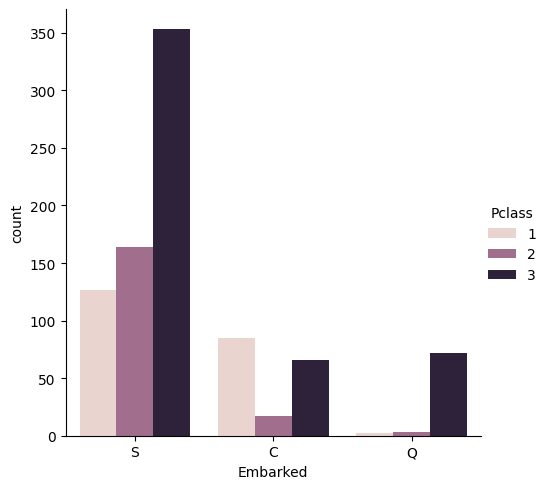

In [46]:
sns.catplot(x='Embarked', data=titanic_df, hue='Pclass',kind='count')

#  2.Data Cleaning

In [50]:
titanic_df['Age'].mean()

np.float64(29.69911764705882)

In [52]:
titanic_df.groupby(by='Pclass')['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [81]:
def m_age( c ):
  Age=c[0]
  Pclass=c[1]
  if pd.isnull(Age):
     if Pclass==1:
        return 38
     elif Pclass==2:
         return 29 
     else: 
         return 25
  else: 
      return('Age')

In [99]:
titanic_df['Age']=titanic_df[['Age', 'Pclass']].apply(m_age, axis=1)

C:\Users\Dell\AppData\Local\Temp\ipykernel_9644\1588569039.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age=c[0]
C:\Users\Dell\AppData\Local\Temp\ipykernel_9644\1588569039.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass=c[1]


<Axes: >

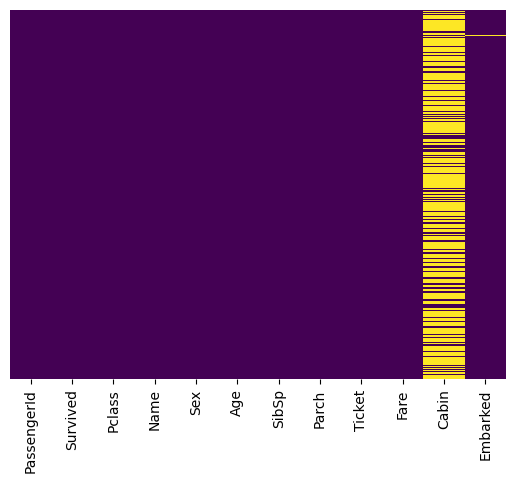

In [83]:
sns.heatmap(titanic_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [84]:
titanic_df.drop('Cabin', axis=1, inplace=True)

<Axes: >

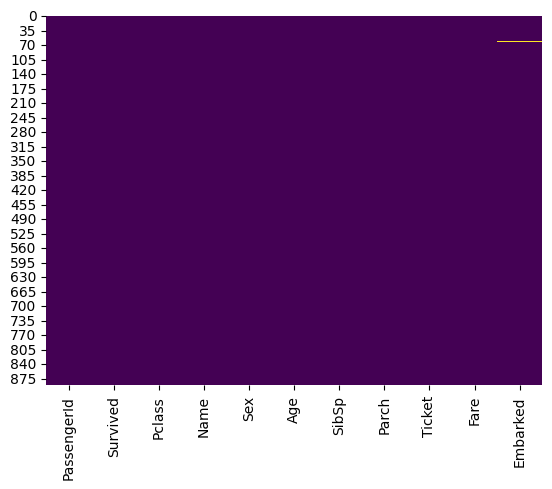

In [85]:
sns.heatmap(titanic_df.isnull(), cbar=False, cmap='viridis')